## Define Connectivity Graph Visualization

Create a NetworkX graph to visualize connectivity between astrocyte regions, including soma, thick branches, and thin processes. Display pairwise connectivity percentages as edge labels.

In [ ]:
# ===================================
# Connectivity before rescaling
# ===================================

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.pyplot as plt

def visualize_connectivity_graph(connectivity_pixel):
    # Define the graph
    connectivity_graph_pixel = nx.Graph()
    
    # Add nodes (Soma, Thick Branches, Thin Processes)
    connectivity_graph_pixel.add_nodes_from(["Soma", "Thick Branches", "Thin Processes"])
    
    # Define the connectivity edges and weights
    connectivity_edges_pixel = {
        ("Soma", "Thick Branches"): connectivity_pixel["Soma ↔ Thick"],
        ("Soma", "Thin Processes"): connectivity_pixel["Soma ↔ Thin"],
        ("Thick Branches", "Thin Processes"): connectivity_pixel["Thick ↔ Thin"],
        ("Thin Processes", "Thin Processes"): connectivity_pixel["Thin ↔ Thin"],
    }
    
    # Add edges with weights (percentages)
    for edge, weight in connectivity_edges_pixel.items():
        connectivity_graph_pixel.add_edge(edge[0], edge[1], weight=weight)
    
    # Define a fixed triangular layout
    pos = {
        "Soma": (0, 1),
        "Thick Branches": (-1, 0),
        "Thin Processes": (1, 0),
    }
    
    # Extract edge weights for labeling
    weights = nx.get_edge_attributes(connectivity_graph_pixel, "weight")
    
    # Visualize the triangular graph
    plt.figure(figsize=(6, 5))
    
    # Draw the graph with nodes
    nx.draw(
        connectivity_graph_pixel,
        pos,
        with_labels=True,
        node_size=2000,
        node_color="lightblue",
        font_size=8,
        font_weight="bold",
    )
    
    # Draw edges with connectivity labels
    nx.draw_networkx_edge_labels(
        connectivity_graph_pixel,
        pos,
        edge_labels={k: f"{v:.2f}%" for k, v in weights.items()},
        font_size=10,
    )
    
    plt.title("Astrocyte Region Connectivity (Final Stronger Connectivity)")
    plt.show()


## Compute Astrocyte Region Connectivity

Load each cropped astrocyte segmentation map, create masks for soma, thick branches, thin processes, and background, compute pixel-based connectivity between regions within a defined neighborhood radius, visualize the connectivity graph for each astrocyte, and save all connectivity metrics to a JSON summary file.

Processed astro_1


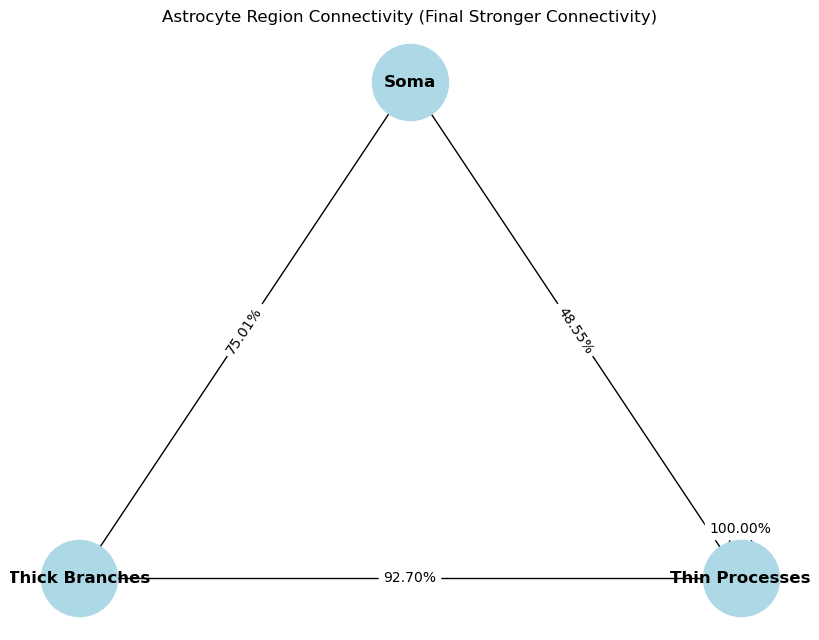


 Saved connectivity summary for all astrocytes to:
Step_2_Connectivity_Healthy/healthy_connectivity_summary.json


In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import json
from skimage.transform import rescale

# =======================================
# Set Directories and Target Soma Size
# =======================================
input_dir = "Step_1_Cropped_Healthy_NPYs"
output_dir = "Step_2_Connectivity_Healthy"
os.makedirs(output_dir, exist_ok=True)

# =======================================
# Store results 
# =======================================
all_connectivity_data = []

# =======================================
# Loop Through Each Astrocyte
# =======================================
for filename in sorted(os.listdir(input_dir)):
    if filename.endswith(".npy"):
        file_path = os.path.join(input_dir, filename)
        segmented_data = np.load(file_path)
        astrocyte_id = filename.split("_")[2].replace(".npy", "")  # e.g., "10", "4", "5"

        # Fixed region labels
        soma_mask = segmented_data == 0
        thick_branch_mask = segmented_data == 1
        thin_process_mask = segmented_data == 2
        background_mask = segmented_data == 3

        def compute_pixel_connectivity(mask1, mask2, radius=100):
            connected_pixels = 0
            total_pixels = np.sum(mask1)
            height, width = mask1.shape

            for i in range(height):
                for j in range(width):
                    if mask1[i, j]:
                        i_min = max(0, i - radius)
                        i_max = min(height, i + radius + 1)
                        j_min = max(0, j - radius)
                        j_max = min(width, j + radius + 1)
                        neighbors = mask2[i_min:i_max, j_min:j_max].ravel()
                        if np.any(neighbors):
                            connected_pixels += 1

            return (connected_pixels / total_pixels) * 100 if total_pixels > 0 else 0

        # =======================================
        # Compute Pixel Connectivity Metrics
        # =======================================
        connectivity_pixel = {
            "Astrocyte": f"astro_{astrocyte_id}",
            "Soma ↔ Thick": compute_pixel_connectivity(thick_branch_mask, soma_mask),
            "Thick ↔ Thin": compute_pixel_connectivity(thin_process_mask, thick_branch_mask),
            "Soma ↔ Thin": compute_pixel_connectivity(thin_process_mask, soma_mask),
            "Thin ↔ Thin": compute_pixel_connectivity(thin_process_mask, thin_process_mask),
            "Soma ↔ Soma": compute_pixel_connectivity(soma_mask, soma_mask),
            "Thick ↔ Thick": compute_pixel_connectivity(thick_branch_mask, thick_branch_mask),
        }
        
        # Append to overall list
        all_connectivity_data.append(connectivity_pixel)
        print(f"Processed astro_{astrocyte_id}")
        visualize_connectivity_graph(connectivity_pixel)
        

# =======================================
# Save All Results as JSON Table
# =======================================
json_output_path = os.path.join(output_dir, "healthy_connectivity_summary.json")
with open(json_output_path, "w") as f:
    json.dump(all_connectivity_data, f, indent=4)

print(f"\n Saved connectivity summary for all astrocytes to:\n{json_output_path}")
